# Batch effect and drift correction for LC-MS

LC-MS untargeted runs suffer from two kinds of unwanted variation that
ComBat alone cannot handle:

1. **Signal drift within a batch** — the injection-time-dependent
   decay of signal due to source fouling, column aging, etc. Drift is
   *continuous* in injection order, not categorical.
2. **Batch shifts between batches** — quantified by ComBat when the
   batch variable is known.

This tutorial shows the recommended combo on a **synthetic LC-MS run
with planted drift + QC pool samples**. Synthetic data lets us verify
that correction works before you apply it to your own study.

Pipeline:

1. `ov.metabol.drift_correct` — per-feature LOESS fit on QC injection order
2. `ov.metabol.serrf` — QC-based Random Forest (Fan 2019) that borrows
   strength from correlated co-features
3. `ov.bulk.batch_correction` — ComBat for residual between-batch shifts


## 0 — Setup and simulated LC-MS run

Simulate 60 samples over 2 batches with 10 QC samples per batch, 40
features. First 15 features have a time-dependent exponential drift;
real samples have a small case/ctrl effect on features 20–24.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from anndata import AnnData
import omicverse as ov

rng = np.random.default_rng(0)

n_real_per_batch = 20
n_qc_per_batch = 10
n_batches = 2
n_features = 40
drift_features = 15
drift_strength = 1.5

rows, idx = [], []
order = 0
for b in range(n_batches):
    plan = ['QC']*n_qc_per_batch + ['real']*n_real_per_batch
    rng.shuffle(plan)
    for k, kind in enumerate(plan):
        rows.append({
            'sample_type': kind,
            'group': 'QC' if kind == 'QC' else ('case' if rng.random() > 0.5 else 'ctrl'),
            'batch': f'b{b}',
            'order': order,
        })
        idx.append(f'b{b}_s{k}')
        order += 1

obs = pd.DataFrame(rows, index=idx)
n = len(obs)

# Baseline signal + drift
X = rng.lognormal(mean=4.0, sigma=0.3, size=(n, n_features))
max_order = float(obs['order'].max())
t = obs['order'].to_numpy() / max_order
X[:, :drift_features] *= np.exp(drift_strength * t)[:, None]

# Inject a between-batch additive shift on features 30-39 (ComBat target)
b_mask = (obs['batch'] == 'b1').to_numpy()
X[b_mask, 30:] *= 1.4

# Tiny biology effect on features 20-24
case = (obs['group'] == 'case').to_numpy()
X[case, 20:25] *= 1.8

var = pd.DataFrame(index=[f'feat{i}' for i in range(n_features)])
adata = AnnData(X=X, obs=obs, var=var)
adata.shape


(60, 40)

## 1 — Baseline: QC CV% before any correction

Features with drift should have inflated CV% on the pool of QC
samples — that is the diagnostic we use to evaluate every correction
step.


In [2]:
def qc_cv_pct(adata, qc_col='sample_type', qc_label='QC', layer=None):
    mask = (adata.obs[qc_col] == qc_label).to_numpy()
    X = adata.X if layer is None else adata.layers[layer]
    X = np.asarray(X)[mask]
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=1)
    return np.where(mu > 0, 100 * sd / mu, np.nan)

cv_raw = qc_cv_pct(adata)
print(f'Before correction — drift features mean CV: {cv_raw[:drift_features].mean():.1f}%')
print(f'                  stable features mean CV: {cv_raw[drift_features:30].mean():.1f}%')


Before correction — drift features mean CV: 52.7%
                  stable features mean CV: 27.0%


## 2 — Step 1: per-feature LOESS drift correction

`drift_correct` fits a LOESS curve through the QC samples on each
feature (independently) and divides every sample's value by that
fitted curve. This is the classic first-pass correction.


In [3]:
adata_drift = ov.metabol.drift_correct(
    adata,
    injection_order='order',
    qc_mask=(adata.obs['sample_type'] == 'QC').to_numpy(),
)
cv_drift = qc_cv_pct(adata_drift)
print(f'After drift_correct — drift features CV: {cv_drift[:drift_features].mean():.1f}%')


After drift_correct — drift features CV: 27.9%


## 3 — Step 2: SERRF

`serrf` borrows strength from *correlated co-features* to model each
feature's expected QC baseline. For drifts that are not monotonic
(e.g. dips + recoveries) SERRF catches what LOESS cannot.

SERRF stores the original matrix in `.layers['raw']` and per-feature
CV% before/after in `.var`:


In [4]:
adata_serrf = ov.metabol.serrf(
    adata,
    qc_col='sample_type', qc_label='QC',
    batch_col='batch',
    top_k=8, n_estimators=100, seed=0,
)

summary = pd.DataFrame({
    'CV_raw': adata_serrf.var['cv_qc_raw'],
    'CV_serrf': adata_serrf.var['cv_qc_serrf'],
})
summary['improvement_%'] = (summary['CV_raw'] - summary['CV_serrf']) / summary['CV_raw'] * 100
summary.head(15)


           CV_raw   CV_serrf  improvement_%
feat0   56.712720  41.317210      27.146485
feat1   50.464151  41.509849      17.743888
feat2   51.106795  28.093674      45.029473
feat3   57.893748  41.949325      27.540836
feat4   54.810053  42.488580      22.480315
feat5   66.226161  43.664605      34.067438
feat6   49.466170  30.746594      37.843189
feat7   46.728802  36.454210      21.987707
feat8   63.352723  32.301074      49.013913
feat9   58.121089  39.154273      32.633276
feat10  53.929962  36.316246      32.660353
feat11  39.701253  30.850989      22.292154
feat12  41.694817  32.690616      21.595491
feat13  50.296132  37.530333      25.381274
feat14  49.698648  29.473423      40.695725

Plot CV% before vs after SERRF on drift features:

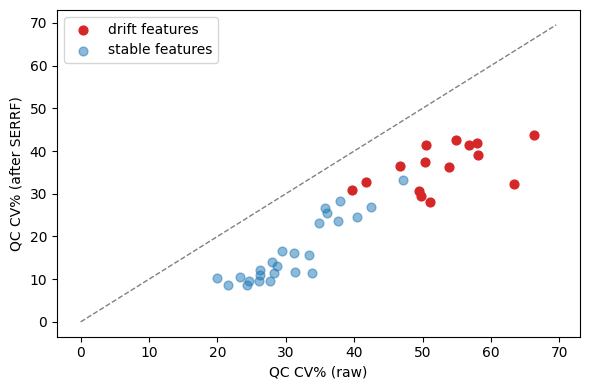

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
is_drift = np.arange(n_features) < drift_features
ax.scatter(summary['CV_raw'][is_drift], summary['CV_serrf'][is_drift],
           color='C3', label='drift features', s=40)
ax.scatter(summary['CV_raw'][~is_drift], summary['CV_serrf'][~is_drift],
           color='C0', label='stable features', s=40, alpha=0.5)
lim = max(summary['CV_raw'].max(), summary['CV_serrf'].max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='gray', lw=1)
ax.set_xlabel('QC CV% (raw)')
ax.set_ylabel('QC CV% (after SERRF)')
ax.legend()
fig.tight_layout()
plt.show()


## 4 — Step 3: ComBat for between-batch shifts

SERRF corrects within-batch drift but assumes you already dealt with
discrete batch shifts. We use `ov.bulk.batch_correction` (which wraps
`combat.pycombat`) for that. It works on any `AnnData` with a batch
column.


In [6]:
ov.bulk.batch_correction(adata_serrf, batch_key='batch',
                           key_added='batch_correction')
print('ComBat output in adata_serrf.layers["batch_correction"]')
print('shape:', adata_serrf.layers['batch_correction'].shape)


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
Storing batch correction result in adata.layers['batch_correction']
ComBat output in adata_serrf.layers["batch_correction"]
shape: (60, 40)


## Summary

For a typical LC-MS study the recommended order is:

```
adata = ov.metabol.drift_correct(adata, injection_order=..., qc_mask=...)
adata = ov.metabol.serrf(adata, qc_col=..., batch_col=...)
ov.bulk.batch_correction(adata, batch_key=...)    # if needed
```

After this, standard downstream steps (`impute`, `normalize`,
`transform`, `differential`, `plsda`/`opls_da`, MSEA) apply without
modification.
